In [20]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [22]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar
!tar -xf images.tar -C ~/work/class_activation_map/
!tar -xf annotation.tar -C ~/work/class_activation_map/
!tar -xf lists.tar -C ~/work/class_activation_map/

print("데이터 다운로드 완료!")

--2026-06-25 06:34:03--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar.6’

images.tar.6        100%[===================>] 756.82M  17.1MB/s    in 86s     

2026-06-25 06:35:29 (8.85 MB/s) - ‘images.tar.6’ saved [793579520/793579520]

--2026-06-25 06:35:29--  http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21852160 (21M) [application/x-tar]
Saving to: ‘annotation.tar.6’

annotation.tar.6    100%[===================>]  20.84M  3.49MB/s    in 9.2s    

2026-06-25 06:35:39 (2.26 MB/s) - ‘a

In [23]:
# 원본 데이터 경로 (압축 해제 후 폴더)
images_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Images')   # 이미지들이 위치한 폴더
mat_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map')   # 프로젝트 루트 디렉토리

# .mat 파일 경로 (train_list.mat와 test_list.mat가 각각 같은 구조라고 가정)
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# train_mat와 test_mat 내부에 'file_list'와 'labels' 등이 있음
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

# 최종적으로 ImageFolder 구조로 재구성할 대상 폴더 생성 (예: stanford_dogs/train, stanford_dogs/test)
base_dir = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir(예: train 혹은 test)에 클래스별 폴더를 생성하고 이미지를 복사
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):
        file_path = file_list_array[idx][0].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 파일 경로 예시: 'n02116738-African_hunting_dog/n02116738_2988.jpg'
        # 클래스 이름은 파일 경로의 최상위 폴더명 (예: 'n02116738-African_hunting_dog')
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 경로: Images 폴더 아래에 file_path 위치
        src_path = os.path.join(images_dir, file_path)
        # 대상 이미지 경로: dest_folder 아래에 원본 파일명 그대로 복사
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")

Processing train set...
Processing test set...
Dataset reorganization complete.


In [24]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [34]:
# 변환(Transform) 정의 (224x224 리사이즈 및 ImageNet 정규화)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 경로 설정 (사용자 환경에 맞춤)
test_dir = os.path.join('stanford_dogs', 'test')
annotation_dir = os.path.join(os.getenv("HOME"), 'work/class_activation_map/Annotation')

# 이미지와 XML 바운딩 박스를 함께 반환하는 커스텀 데이터셋 클래스
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        bbox = [0.0, 0.0, 0.0, 0.0]  # 기본값 [xmin, ymin, xmax, ymax]

        if os.path.exists(annot_path):
            try:
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        
                        # 원본 이미지 크기 대비 224x224로 좌표 스케일링 변환
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        return image, label, bbox

# 검증 데이터셋 및 데이터로더 생성
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)
valid_loader = DataLoader(valid_dataset, batch_size=12, shuffle=False, num_workers=2)

num_classes = len(valid_dataset.classes)
print(f"클래스 수: {num_classes}, 검증 샘플 수: {len(valid_dataset)}")

클래스 수: 120, 검증 샘플 수: 8580


In [35]:
def cam_to_bbox(heatmap, threshold=0.5):
    """
    CAM/Grad-CAM 히트맵에서 임계값 이상인 영역을 감싸는 바운딩 박스 [xmin, ymin, xmax, ymax] 추출
    """
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    _, thresh = cv2.threshold((heatmap_resized * 255).astype(np.uint8), int(threshold * 255), 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return [0.0, 0.0, 0.0, 0.0]
    
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    return [float(x), float(y), float(x + w), float(y + h)]


def calculate_iou(boxA, boxB):
    """
    두 바운딩 박스 [xmin, ymin, xmax, ymax] 간의 IoU 계산
    """
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])
    
    interArea = max(0, xB - xA) * max(0, yB - yA)
    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
    unionArea = boxAArea + boxBArea - interArea
    
    if unionArea == 0:
        return 0.0
    return interArea / unionArea

Backbone모델(ResNev 50 vs ResNet 101)

In [36]:
# ResNet-50 
model_50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model_50.fc = nn.Linear(model_50.fc.in_features, num_classes)
model_50 = model_50.to(device).eval()

# ResNet-101 
model_101 = models.resnet101(weights=models.ResNet101_Weights.DEFAULT)
model_101.fc = nn.Linear(model_101.fc.in_features, num_classes)
model_101 = model_101.to(device).eval()

CAM 

In [37]:
def get_cam(model, input_tensor, class_idx):
    features = []
    def hook_fn(module, input, output):
        features.append(output.detach())
        
    handle = model.layer4.register_forward_hook(hook_fn)
    _ = model(input_tensor)
    handle.remove()
    
    act_maps = features[0].squeeze(0)
    fc_weights = model.fc.weight.detach().cpu().numpy()
    target_weights = fc_weights[class_idx]
    
    cam = np.zeros(act_maps.shape[1:], dtype=np.float32)
    act_maps = act_maps.cpu().numpy()
    for i, w in enumerate(target_weights):
        cam += w * act_maps[i]
        
    cam = np.maximum(cam, 0)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam

GradCAM

In [38]:
class GradCAM_Comparison:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
        
    def generate_heatmap(self, input_tensor, class_idx):
        self.model.zero_grad()
        output = self.model(input_tensor)
        loss = output[0, class_idx]
        loss.backward()
        
        alpha = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        grad_cam = torch.sum(alpha * self.activations, dim=1).squeeze(0)
        grad_cam = F.relu(grad_cam)
        grad_cam = grad_cam - grad_cam.min()
        grad_cam = grad_cam / (grad_cam.max() + 1e-8)
        return grad_cam.cpu().numpy()

비교실험 / 시각화 

🎯 [Sample 10] 견종: n02085620-Chihuahua 크로스 비교 결과
--------------------------------------------------
[ResNet-50 + CAM] IoU Score: 0.0951
[ResNet-50 + Grad-CAM] IoU Score: 0.0951
[ResNet-101 + CAM] IoU Score: 0.0454
[ResNet-101 + Grad-CAM] IoU Score: 0.0454


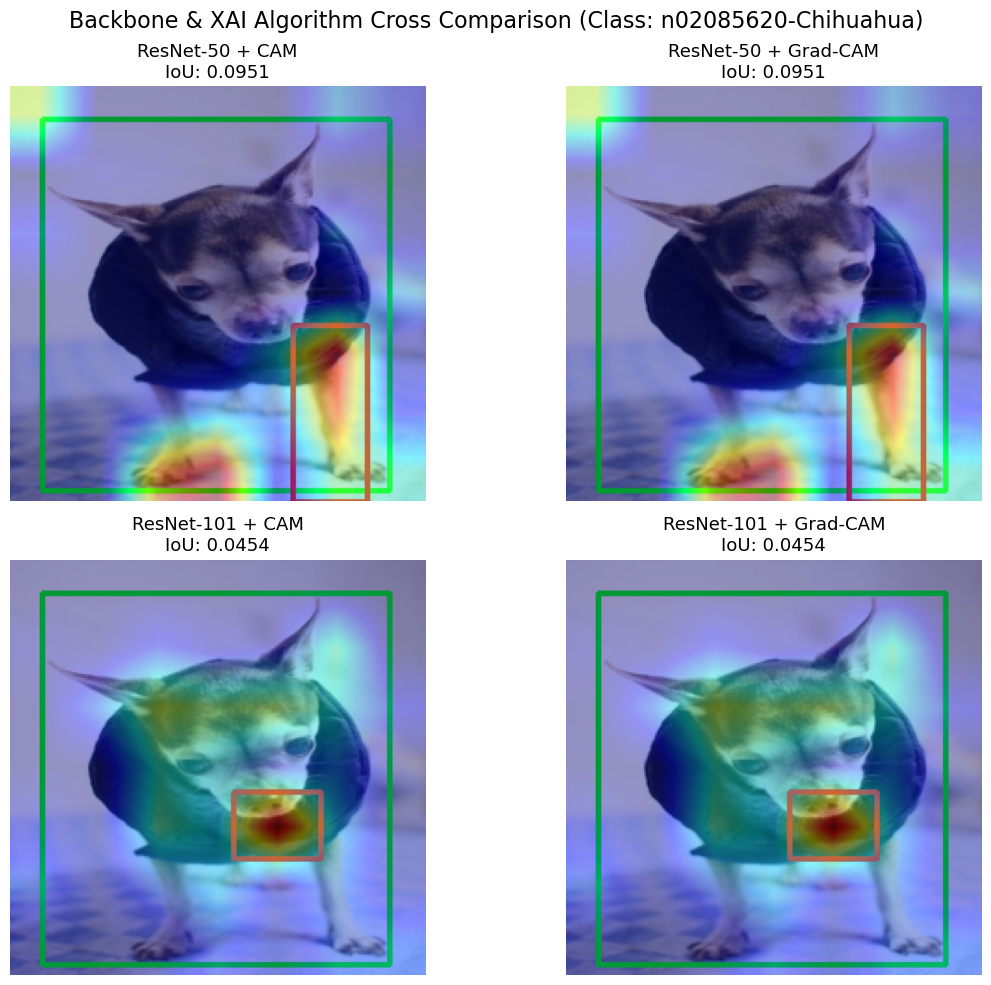

In [43]:
def run_cross_comparison(sample_idx, threshold=0.5):
    img_tensor, label, gt_bbox = valid_dataset[sample_idx]
    
    # 각 백본 모델용 독립 텐서 생성
    input_tensor_50 = img_tensor.unsqueeze(0).to(device)
    input_tensor_50.requires_grad = True
    input_tensor_101 = img_tensor.unsqueeze(0).to(device)
    input_tensor_101.requires_grad = True
    
    # Grad-CAM 생성기 설정
    gcam_50 = GradCAM_Comparison(model_50, model_50.layer4)
    gcam_101 = GradCAM_Comparison(model_101, model_101.layer4)
    
    # 4가지 실험 조합 매핑
    heatmaps = {
        'ResNet-50 + CAM': get_cam(model_50, input_tensor_50, label),
        'ResNet-50 + Grad-CAM': gcam_50.generate_heatmap(input_tensor_50, label),
        'ResNet-101 + CAM': get_cam(model_101, input_tensor_101, label),
        'ResNet-101 + Grad-CAM': gcam_101.generate_heatmap(input_tensor_101, label)
    }
    
    # 시각화용 이미지 역정규화 복원
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    orig_img = img_tensor.permute(1, 2, 0).numpy()
    orig_img = std * orig_img + mean
    orig_img = np.clip(orig_img, 0, 1)
    orig_img = (orig_img * 255).astype(np.uint8)
    
    # 2x2 격자 시각화 플롯 설정
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    print(f"🎯 [Sample {sample_idx}] 견종: {valid_dataset.classes[label]} 크로스 비교 결과\n" + "-"*50)
    
    for idx, (title, hmap) in enumerate(heatmaps.items()):
        # 예측 박스 연산 및 IoU 산출
        pred_bbox = cam_to_bbox(hmap, threshold=threshold)
        iou_score = calculate_iou(gt_bbox, pred_bbox)
        
        print(f"[{title}] IoU Score: {iou_score:.4f}")
        
        # 이미지에 박스 렌더링 (정답: 초록 / 예측: 빨강)
        display_img = orig_img.copy()
        cv2.rectangle(display_img, (int(gt_bbox[0]), int(gt_bbox[1])), (int(gt_bbox[2]), int(gt_bbox[3])), (0, 255, 0), 2)
        cv2.rectangle(display_img, (int(pred_bbox[0]), int(pred_bbox[1])), (int(pred_bbox[2]), int(pred_bbox[3])), (255, 0, 0), 2)
        
        # 히트맵 알파 블렌딩 합성
        hmap_resized = cv2.resize(hmap, (224, 224))
        hmap_color = cv2.applyColorMap(np.uint8(255 * hmap_resized), cv2.COLORMAP_JET)
        hmap_color = cv2.cvtColor(hmap_color, cv2.COLOR_BGR2RGB)
        blended = cv2.addWeighted(display_img, 0.6, hmap_color, 0.4, 0)
        
        # 개별 이미지 플롯팅
        axes[idx].imshow(blended)
        axes[idx].set_title(f"{title}\nIoU: {iou_score:.4f}", fontsize=13)
        axes[idx].axis('off')
        
    plt.suptitle(f"Backbone & XAI Algorithm Cross Comparison (Class: {valid_dataset.classes[label]})", fontsize=16, y=0.98)
    plt.tight_layout()
    plt.show()

# 테스트 데이터셋의 0번째 이미지로 크로스 매트릭스 비교 진행
run_cross_comparison(sample_idx=10, threshold=0.5)

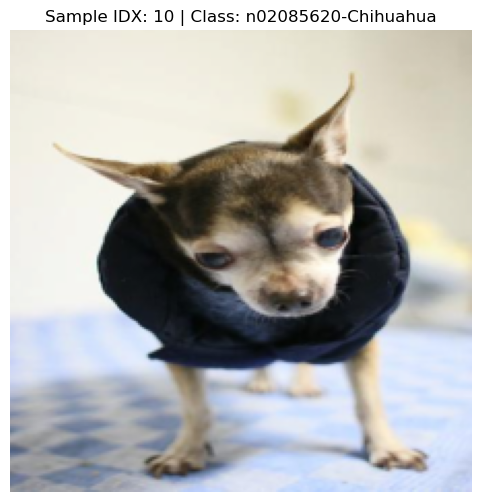

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def display_original_sample(sample_idx):
    """
    valid_dataset에서 지정한 인덱스의 원본 이미지를 
    역정규화(De-normalization)하여 화면에 출력합니다.
    """
    # 데이터셋에서 이미지 텐서, 라벨, 정답 바운딩 박스 가져오기
    img_tensor, label, gt_bbox = valid_dataset[sample_idx]
    
    # 1. PyTorch 텐서 형태 (채널, 세로, 가로) -> 시각화용 NumPy 형태 (세로, 가로, 채널)로 변환
    img_np = img_tensor.permute(1, 2, 0).numpy()
    
    # 2. 모델 학습 시 적용했던 정규화(Normalize) 과정을 역산하여 원본 색상 복원
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = std * img_np + mean
    
    # 3. 역산 과정에서 0과 1 범위를 미세하게 벗어난 값들을 안전하게 잘라내기(clipping)
    img_np = np.clip(img_np, 0, 1)
    
    # 4. Matplotlib을 이용한 화면 출력
    plt.figure(figsize=(6, 6))
    plt.imshow(img_np)
    plt.title(f"Sample IDX: {sample_idx} | Class: {valid_dataset.classes[label]}", fontsize=12)
    plt.axis('off') # 격자선 숨기기
    plt.show()

# ==========================================
# 실행부: 확인하고 싶은 샘플의 인덱스를 넣으세요
# ==========================================
# 첫 번째 치와와 이미지 (정면 응시하고 있던 샘플)
display_original_sample(sample_idx=10)